In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib
import os

DATA_DIR = r"C:\Users\arnaw\OneDrive\Desktop\transfer_recomender\data"
MODELS_DIR = r"C:\Users\arnaw\OneDrive\Desktop\transfer_recomender\models"
os.makedirs(MODELS_DIR, exist_ok=True)

fw = pd.read_csv(os.path.join(DATA_DIR, "fw_cleaned.csv"))
mf = pd.read_csv(os.path.join(DATA_DIR, "mf_cleaned.csv"))
df = pd.read_csv(os.path.join(DATA_DIR, "df_cleaned.csv"))

print(f"FW: {fw.shape}")
print(f"MF: {mf.shape}")
print(f"DF: {df.shape}")

FW: (720, 222)
MF: (900, 222)
DF: (1022, 222)


Finding best K for Forwards...


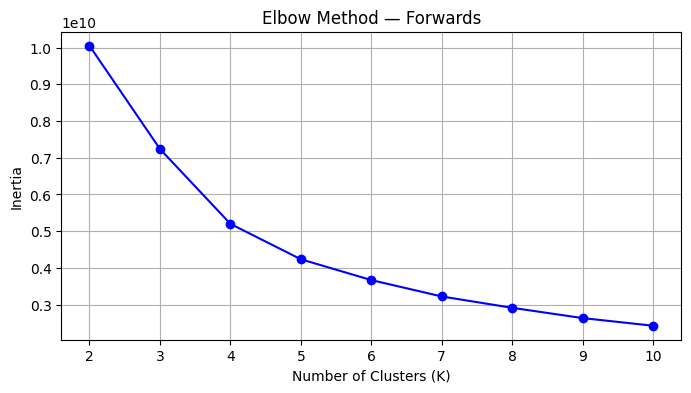

Finding best K for Midfielders...


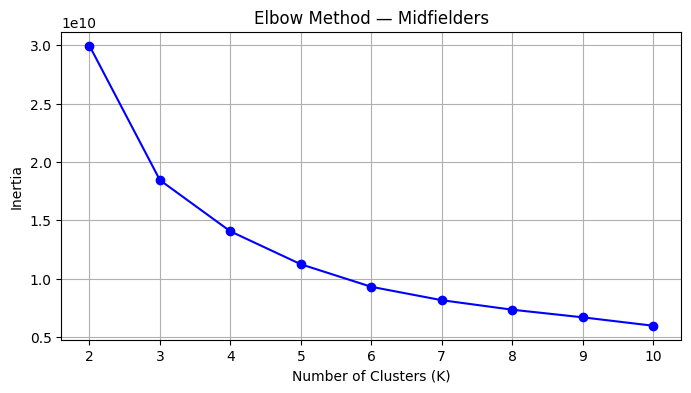

Finding best K for Defenders...


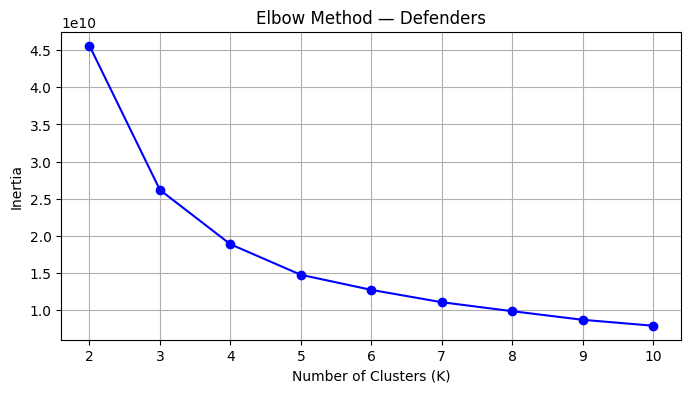

In [3]:
# Cell 2: Elbow Method to find best K
def find_best_k(data, position_name, max_k=10):
    # drop non-numeric columns
    numeric_data = data.select_dtypes(include=[np.number])
    
    # drop any remaining NaN values
    numeric_data = numeric_data.fillna(0)
    
    inertias = []
    k_range = range(2, max_k+1)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(numeric_data)
        inertias.append(kmeans.inertia_)
    
    # Plot
    plt.figure(figsize=(8,4))
    plt.plot(k_range, inertias, 'bo-')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Inertia')
    plt.title(f'Elbow Method — {position_name}')
    plt.xticks(k_range)
    plt.grid(True)
    plt.show()
    
    return inertias

# Run for each position
print("Finding best K for Forwards...")
fw_inertias = find_best_k(fw, "Forwards")

print("Finding best K for Midfielders...")
mf_inertias = find_best_k(mf, "Midfielders")

print("Finding best K for Defenders...")
df_inertias = find_best_k(df, "Defenders")

In [5]:
K_FW = 5
K_MF = 6
K_DF = 5

def fit_kmeans(data, k, position_name):
    numeric_data = data.select_dtypes(include=[np.number]).fillna(0)
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(numeric_data)
    
    print(f"{position_name} — K={k}, Inertia={kmeans.inertia_:.2f}")
    return kmeans

fw_kmeans = fit_kmeans(fw, K_FW, "Forwards")
mf_kmeans = fit_kmeans(mf, K_MF, "Midfielders")
df_kmeans = fit_kmeans(df, K_DF, "Defenders")

Forwards — K=5, Inertia=4235061000.73
Midfielders — K=6, Inertia=9304072768.00
Defenders — K=5, Inertia=14761523163.59


In [6]:
def assign_clusters(data, kmeans_model, position_name):
    numeric_data = data.select_dtypes(include=[np.number]).fillna(0)
    
    data = data.copy()
    data['cluster'] = kmeans_model.predict(numeric_data)
    
    print(f"{position_name} cluster distribution:")
    print(data['cluster'].value_counts().sort_index())
    print()
    
    return data

fw_clustered = assign_clusters(fw, fw_kmeans, "Forwards")
mf_clustered = assign_clusters(mf, mf_kmeans, "Midfielders")
df_clustered = assign_clusters(df, df_kmeans, "Defenders")

Forwards cluster distribution:
cluster
0    211
1    111
2    224
3     60
4    114
Name: count, dtype: int64

Midfielders cluster distribution:
cluster
0    185
1    110
2    216
3     17
4    188
5    184
Name: count, dtype: int64

Defenders cluster distribution:
cluster
0    232
1    317
2     58
3    168
4    247
Name: count, dtype: int64



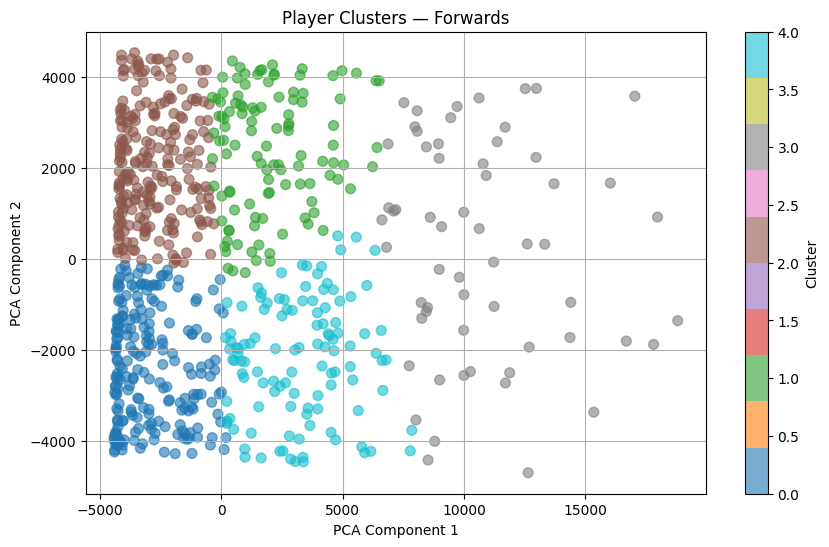

Variance explained: 95.2%


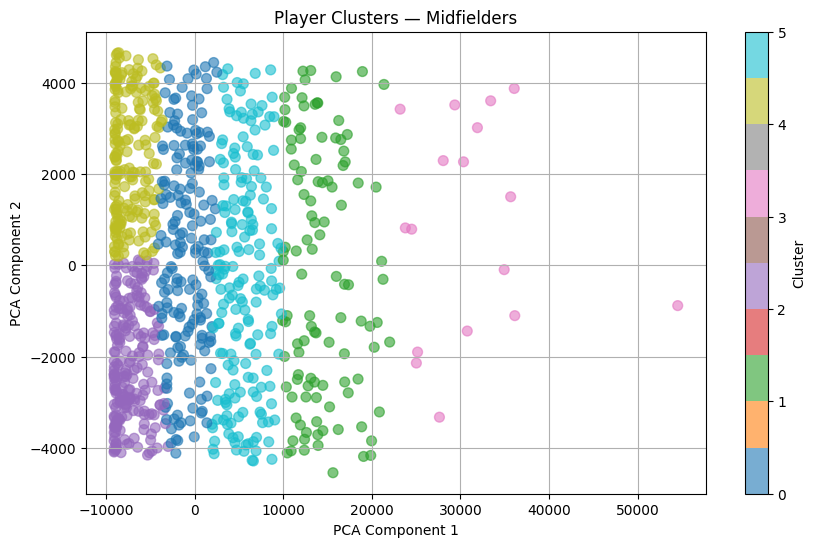

Variance explained: 98.0%


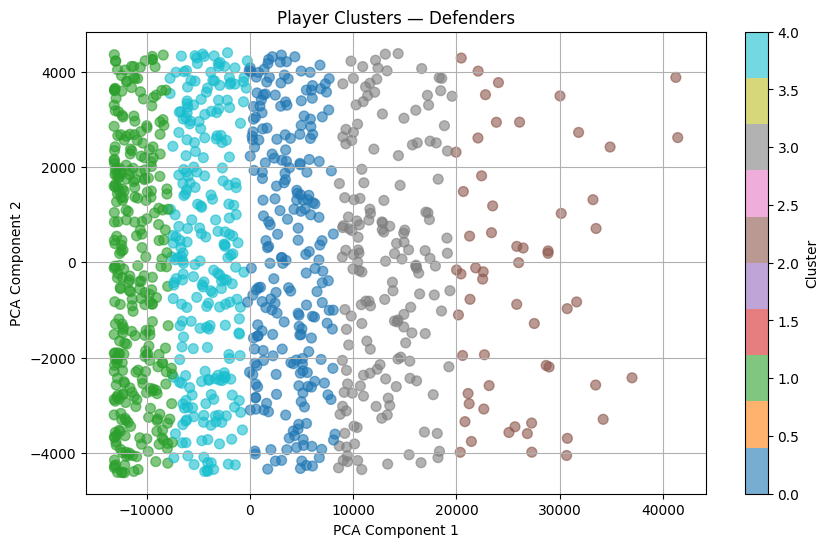

Variance explained: 98.6%


In [7]:
def visualize_clusters(data, position_name):
    numeric_data = data.select_dtypes(include=[np.number]).fillna(0)
    
    features = numeric_data.drop('cluster', axis=1)
    
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(features)
    
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        pca_result[:, 0],
        pca_result[:, 1],
        c=data['cluster'],
        cmap='tab10',
        alpha=0.6,
        s=50
    )
    plt.colorbar(scatter, label='Cluster')
    plt.title(f'Player Clusters — {position_name}')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.grid(True)
    plt.show()
    
    print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

visualize_clusters(fw_clustered, "Forwards")
visualize_clusters(mf_clustered, "Midfielders")
visualize_clusters(df_clustered, "Defenders")

In [11]:
# Cell 6: Interpret Clusters (Fixed)
def interpret_clusters(data, position_name, key_stats):
    print(f"\n{'='*50}")
    print(f"{position_name} — Cluster Profiles")
    print(f"{'='*50}")
    
    # only use stats that exist in the dataframe
    available = [s for s in key_stats if s in data.columns]
    
    cluster_means = data.groupby('cluster')[available].mean()
    print(cluster_means.round(2))
    print()

# Define key stats per position
fw_stats = ['Gls', 'Ast', 'Sh', 'SoT', 'G/Sh', 'Dist', 'KP', 'PrgP']
mf_stats = ['Ast', 'KP', 'PrgP', 'PrgC', 'Tkl', 'Int', 'Gls', 'PPA']
df_stats = ['Tkl', 'Int', 'Clr', 'PrgP', 'KP', 'Blocks', 'Err']  # removed AerWon

interpret_clusters(fw_clustered, "Forwards", fw_stats)
interpret_clusters(mf_clustered, "Midfielders", mf_stats)
interpret_clusters(df_clustered, "Defenders", df_stats)


Forwards — Cluster Profiles
          Gls   Ast     Sh    SoT  G/Sh   Dist     KP    PrgP
cluster                                                      
0        1.47  0.53  11.71   4.27  0.10  16.01   4.91    9.22
1        6.86  2.91  44.54  16.86  0.12  16.26  22.52   42.25
2        1.34  0.50  11.79   4.29  0.09  15.04   4.78    8.98
3        8.88  6.17  64.17  24.53  0.12  17.53  49.72  108.28
4        7.04  3.04  48.41  18.53  0.12  16.33  25.32   50.20


Midfielders — Cluster Profiles
          Ast     KP    PrgP   PrgC    Tkl    Int   Gls    PPA
cluster                                                       
0        1.51  15.83   56.38  23.66  27.49  11.29  1.83  12.15
1        3.14  31.62  151.13  42.00  56.13  25.93  2.79  26.37
2        0.41   4.10   12.24   7.64   7.03   2.49  0.51   3.02
3        4.71  48.12  261.88  53.71  60.71  31.24  3.06  43.24
4        0.28   3.52   11.91   5.09   6.64   2.53  0.44   2.53
5        2.34  23.95   96.49  36.20  41.45  19.51  2.82  19.18


In [13]:
joblib.dump(fw_kmeans, os.path.join(MODELS_DIR, "fw_kmeans.pkl"))
joblib.dump(mf_kmeans, os.path.join(MODELS_DIR, "mf_kmeans.pkl"))
joblib.dump(df_kmeans, os.path.join(MODELS_DIR, "df_kmeans.pkl"))

fw_clustered.to_csv(os.path.join(DATA_DIR, "fw_clustered.csv"), index=False)
mf_clustered.to_csv(os.path.join(DATA_DIR, "mf_clustered.csv"), index=False)
df_clustered.to_csv(os.path.join(DATA_DIR, "df_clustered.csv"), index=False)

print("Models saved:")
print(f"  ✅ fw_kmeans.pkl")
print(f"  ✅ mf_kmeans.pkl")
print(f"  ✅ df_kmeans.pkl")
print("\nCSVs saved:")
print(f"  ✅ fw_clustered.csv")
print(f"  ✅ mf_clustered.csv")
print(f"  ✅ df_clustered.csv")

Models saved:
  ✅ fw_kmeans.pkl
  ✅ mf_kmeans.pkl
  ✅ df_kmeans.pkl

CSVs saved:
  ✅ fw_clustered.csv
  ✅ mf_clustered.csv
  ✅ df_clustered.csv
